In [ ]:
import kagglehub
path = kagglehub.dataset_download("mohansacharya/graduate-admissions")

Using Colab cache for faster access to the 'graduate-admissions' dataset.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import r2_score
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense



In [ ]:
import os

# List the contents of the downloaded directory to find the CSV file
dataset_files = os.listdir(path)
print(f"Files in the dataset directory: {dataset_files}")

# Correcting the CSV file name based on the output of os.listdir()
csv_file_path = os.path.join(path, 'Admission_Predict.csv')

df = pd.read_csv(csv_file_path)
df.head()

Files in the dataset directory: ['Admission_Predict.csv', 'Admission_Predict_Ver1.1.csv']


,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,1,337,118,4,4.5,4.5,9.65,1,0.92
1,2,324,107,4,4.0,4.5,8.87,1,0.76
2,3,316,104,3,3.0,3.5,8.00,1,0.72
3,4,322,110,3,3.5,2.5,8.67,1,0.80
4,5,314,103,2,2.0,3.0,8.21,0,0.65


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Serial No.         400 non-null    int64  
 1   GRE Score          400 non-null    int64  
 2   TOEFL Score        400 non-null    int64  
 3   University Rating  400 non-null    int64  
 4   SOP                400 non-null    float64
 5   LOR                400 non-null    float64
 6   CGPA               400 non-null    float64
 7   Research           400 non-null    int64  
 8   Chance of Admit    400 non-null    float64
dtypes: float64(4), int64(5)
memory usage: 28.3 KB


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df=df.drop("Serial No.", axis=1)

In [ ]:
x=df.drop('Chance of Admit ', axis=1)
y=df['Chance of Admit ']

In [ ]:
df.columns

Index(['GRE Score', 'TOEFL Score', 'University Rating', 'SOP', 'LOR ', 'CGPA',
       'Research', 'Chance of Admit '],
      dtype='object')

In [ ]:
x

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research
0,337,118,4,4.5,4.5,9.65,1
1,324,107,4,4.0,4.5,8.87,1
2,316,104,3,3.0,3.5,8.00,1
3,322,110,3,3.5,2.5,8.67,1
4,314,103,2,2.0,3.0,8.21,0
...,...,...,...,...,...,...,...
395,324,110,3,3.5,3.5,9.04,1
396,325,107,3,3.0,3.5,9.11,1
397,330,116,4,5.0,4.5,9.45,1
398,312,103,3,3.5,4.0,8.78,0


In [ ]:
y

,Chance of Admit
0,0.92
1,0.76
2,0.72
3,0.80
4,0.65
...,...
395,0.82
396,0.84
397,0.91
398,0.67


In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
scaler=MinMaxScaler()
x_train_scler=scaler.fit_transform(x_train)
x_test_scaler=scaler.fit_transform(x_test)
print(x_train_scler)
print(x_test_scaler)

[[0.64       0.64285714 0.5        ... 0.375      0.59935897 1.        ]
 [0.56       0.64285714 0.5        ... 0.5        0.64102564 0.        ]
 [1.         1.         1.         ... 0.875      0.99679487 1.        ]
 ...
 [0.32       0.46428571 0.25       ... 0.5        0.45512821 1.        ]
 [0.24       0.25       0.         ... 0.25       0.14423077 0.        ]
 [0.48       0.5        0.25       ... 0.625      0.46474359 0.        ]]
[[0.11363636 0.36       0.5        0.57142857 0.71428571 0.29752066
  1.        ]
 [0.34090909 0.28       0.5        0.85714286 0.71428571 0.51239669
  1.        ]
 [1.         0.76       1.         0.71428571 0.71428571 0.90909091
  1.        ]
 [0.65909091 0.52       0.75       0.85714286 0.71428571 0.68595041
  1.        ]
 [0.11363636 0.08       0.25       0.42857143 0.42857143 0.19834711
  1.        ]
 [1.         0.8        1.         0.85714286 0.85714286 0.84710744
  1.        ]
 [0.02272727 0.04       0.25       0.28571429 0.         0.20247

In [ ]:
model=Sequential()
model.add(Dense(7,activation='relu', input_dim=7))
model.add(Dense(1, activation='linear'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 7)              │            56 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │             8 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 64 (256.00 B)

 Trainable params: 64 (256.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(loss="mean_squared_error", optimizer="Adam", metrics=["accuracy"])

In [ ]:
history=model.fit(x_train_scler,y_train,epochs=100,validation_split=0.2)

Epoch 1/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - accuracy: 0.0000e+00 - loss: 0.4681 - val_accuracy: 0.0000e+00 - val_loss: 0.5404
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.0000e+00 - loss: 0.3904 - val_accuracy: 0.0000e+00 - val_loss: 0.4537
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.0000e+00 - loss: 0.3194 - val_accuracy: 0.0000e+00 - val_loss: 0.3717
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.0000e+00 - loss: 0.2539 - val_accuracy: 0.0000e+00 - val_loss: 0.2964
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.0000e+00 - loss: 0.1957 - val_accuracy: 0.0000e+00 - val_loss: 0.2304
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.0000e+00 - loss: 0.1465 - val_accuracy: 0.0000e+00 - val_loss: 0.1752
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.0000e+00 - loss: 0.1071 - val_accuracy: 0.0000e+00 - val_loss: 0.1298
Epoch 8/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 

In [ ]:
y_pred=model.predict(x_test)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step


In [ ]:
r2_score(y_test, y_pred)

-118970.03783173475

In [ ]:
model=Sequential()
model.add(Dense(7,activation='relu', input_dim=7))
model.add(Dense(7, activation='relu'))
model.add(Dense(1, activation='linear'))
model.compile(loss="mean_squared_error", optimizer="Adam", metrics=["accuracy"])
history=model.fit(x_train_scler,y_train,epochs=100,validation_split=0.2)
y_pred=model.predict(x_test)
r2_score(y_test, y_pred)

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - accuracy: 0.0000e+00 - loss: 1.6836 - val_accuracy: 0.0000e+00 - val_loss: 1.4159
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.0000e+00 - loss: 1.4181 - val_accuracy: 0.0000e+00 - val_loss: 1.2425
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.0000e+00 - loss: 1.2243 - val_accuracy: 0.0000e+00 - val_loss: 1.1129
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.0000e+00 - loss: 1.0784 - val_accuracy: 0.0000e+00 - val_loss: 1.0096
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.0000e+00 - loss: 0.9630 - val_accuracy: 0.0000e+00 - val_loss: 0.9236
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.0000e+00 - loss: 0.8708 - val_accuracy: 0.0000e+00 - val_loss: 0.8514
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.0000e+00 - loss: 0.7940 - val_accuracy: 0.0000e+00 - val_loss: 0.7886
Epoch 8/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.0000e+00 -

-123361.82138505677

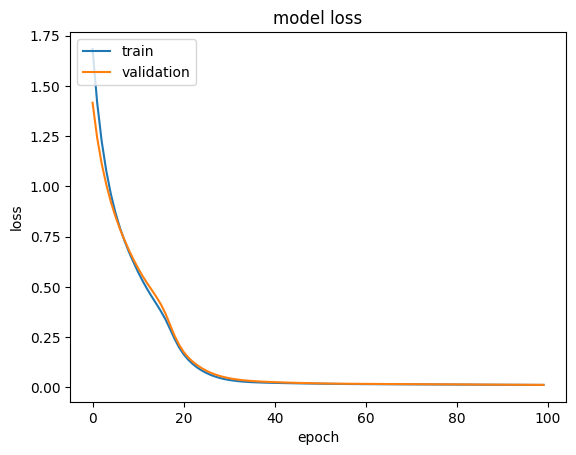

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')